# ORACLE Cross-Dataset Evaluation

Full retrieve-generate pipeline evaluated across all six corpus sources
(medmcqa, medqa, mirage, plaba, pubmed, pubmedqa), with a paired
upper-bound comparison isolating the effect of literacy-band routing
accuracy from retrieval quality.

Decision 16: routing accuracy significantly affects FK reduction
(p=0.032) but not ROUGE-L or BERTScore (p=0.53, p=0.61), since
retrieved content is held fixed across the paired comparison and only
the band prompt differs.

Note: re-running the generation cell below repeats all 144 calls
against the OpenAI API. Skip it if `cross_dataset_results.csv`
already reflects the run you want to inspect; the figure-generation
cell reads from that CSV and is safe to re-run any time.

In [1]:
import sys, os, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
from cross_dataset_eval import run_cross_dataset_eval
from cross_dataset_figures import run_figures

In [2]:
# results = run_cross_dataset_eval()  # uncomment to regenerate from scratch (API cost + ~20 min)
import pandas as pd
results = pd.read_csv('../data/processed/cross_dataset_results.csv')

In [3]:
actual = results[results['condition'] == 'actual']
summary = actual.groupby('source').agg(
    n=('query', 'count'),
    band_accuracy=('band_match', 'mean'),
    mean_fk_source=('fk_source', 'mean'),
    mean_fk_generated=('fk_generated', 'mean'),
    mean_fk_reduction=('fk_reduction', 'mean'),
    mean_rouge_l=('rouge_l', 'mean'),
    mean_bertscore=('bertscore', 'mean')
).round(3)
print(summary.to_string())

           n  band_accuracy  mean_fk_source  mean_fk_generated  mean_fk_reduction  mean_rouge_l  mean_bertscore
source                                                                                                         
medmcqa   20          1.000          10.486             13.231             -1.956         0.163           0.836
medqa     20          0.750          10.067             12.976             -2.909         0.031           0.803
mirage    20          0.250          10.913             13.572             -1.783         0.048           0.798
plaba     15          1.000          12.632             14.493             -1.861         0.305           0.856
pubmed    15          0.400          12.633             17.802             -5.169         0.181           0.849
pubmedqa  16          0.438          12.142             16.819             -4.677         0.130           0.850


## Routing-Readability Finding

Paired Wilcoxon signed-rank test, misrouted-band generation vs the same
query regenerated with the correct band and identical retrieved context.

In [4]:
from scipy.stats import wilcoxon

wrong = actual[actual['band_match'] == False].copy()
upper = results[results['condition'] == 'upper_bound'].copy()
wrong_p = wrong.set_index(['source', 'query'])
upper_p = upper.set_index(['source', 'query'])
paired = wrong_p.join(upper_p, lsuffix='_wrong', rsuffix='_upper', how='inner')

for col, label in [('fk_reduction', 'FK Reduction'), ('rouge_l', 'ROUGE-L'), ('bertscore', 'BERTScore')]:
    a = paired[col + '_wrong'].dropna()
    b = paired[col + '_upper'].dropna()
    common = a.index.intersection(b.index)
    a, b = a.loc[common], b.loc[common]
    stat, p = wilcoxon(a, b)
    print(f'{label}: wrong={a.mean():.3f} upper_bound={b.mean():.3f}  p={p:.4f}  n={len(a)}')

FK Reduction: wrong=-3.713 upper_bound=-2.311  p=0.0319  n=38
ROUGE-L: wrong=0.079 upper_bound=0.081  p=0.5304  n=38
BERTScore: wrong=0.815 upper_bound=0.816  p=0.6055  n=38


## Figures

Regenerates all four figures from `cross_dataset_results.csv`, then
displays them below. Safe to re-run whenever the results CSV changes.

In [5]:
run_figures()

Saved: cross_dataset_fk_comparison.png
Saved: cross_dataset_routing_rouge.png
Saved: cross_dataset_fk_by_band.png


Saved: cross_dataset_routing_impact.png

All 4 figures saved to figures/stage4/


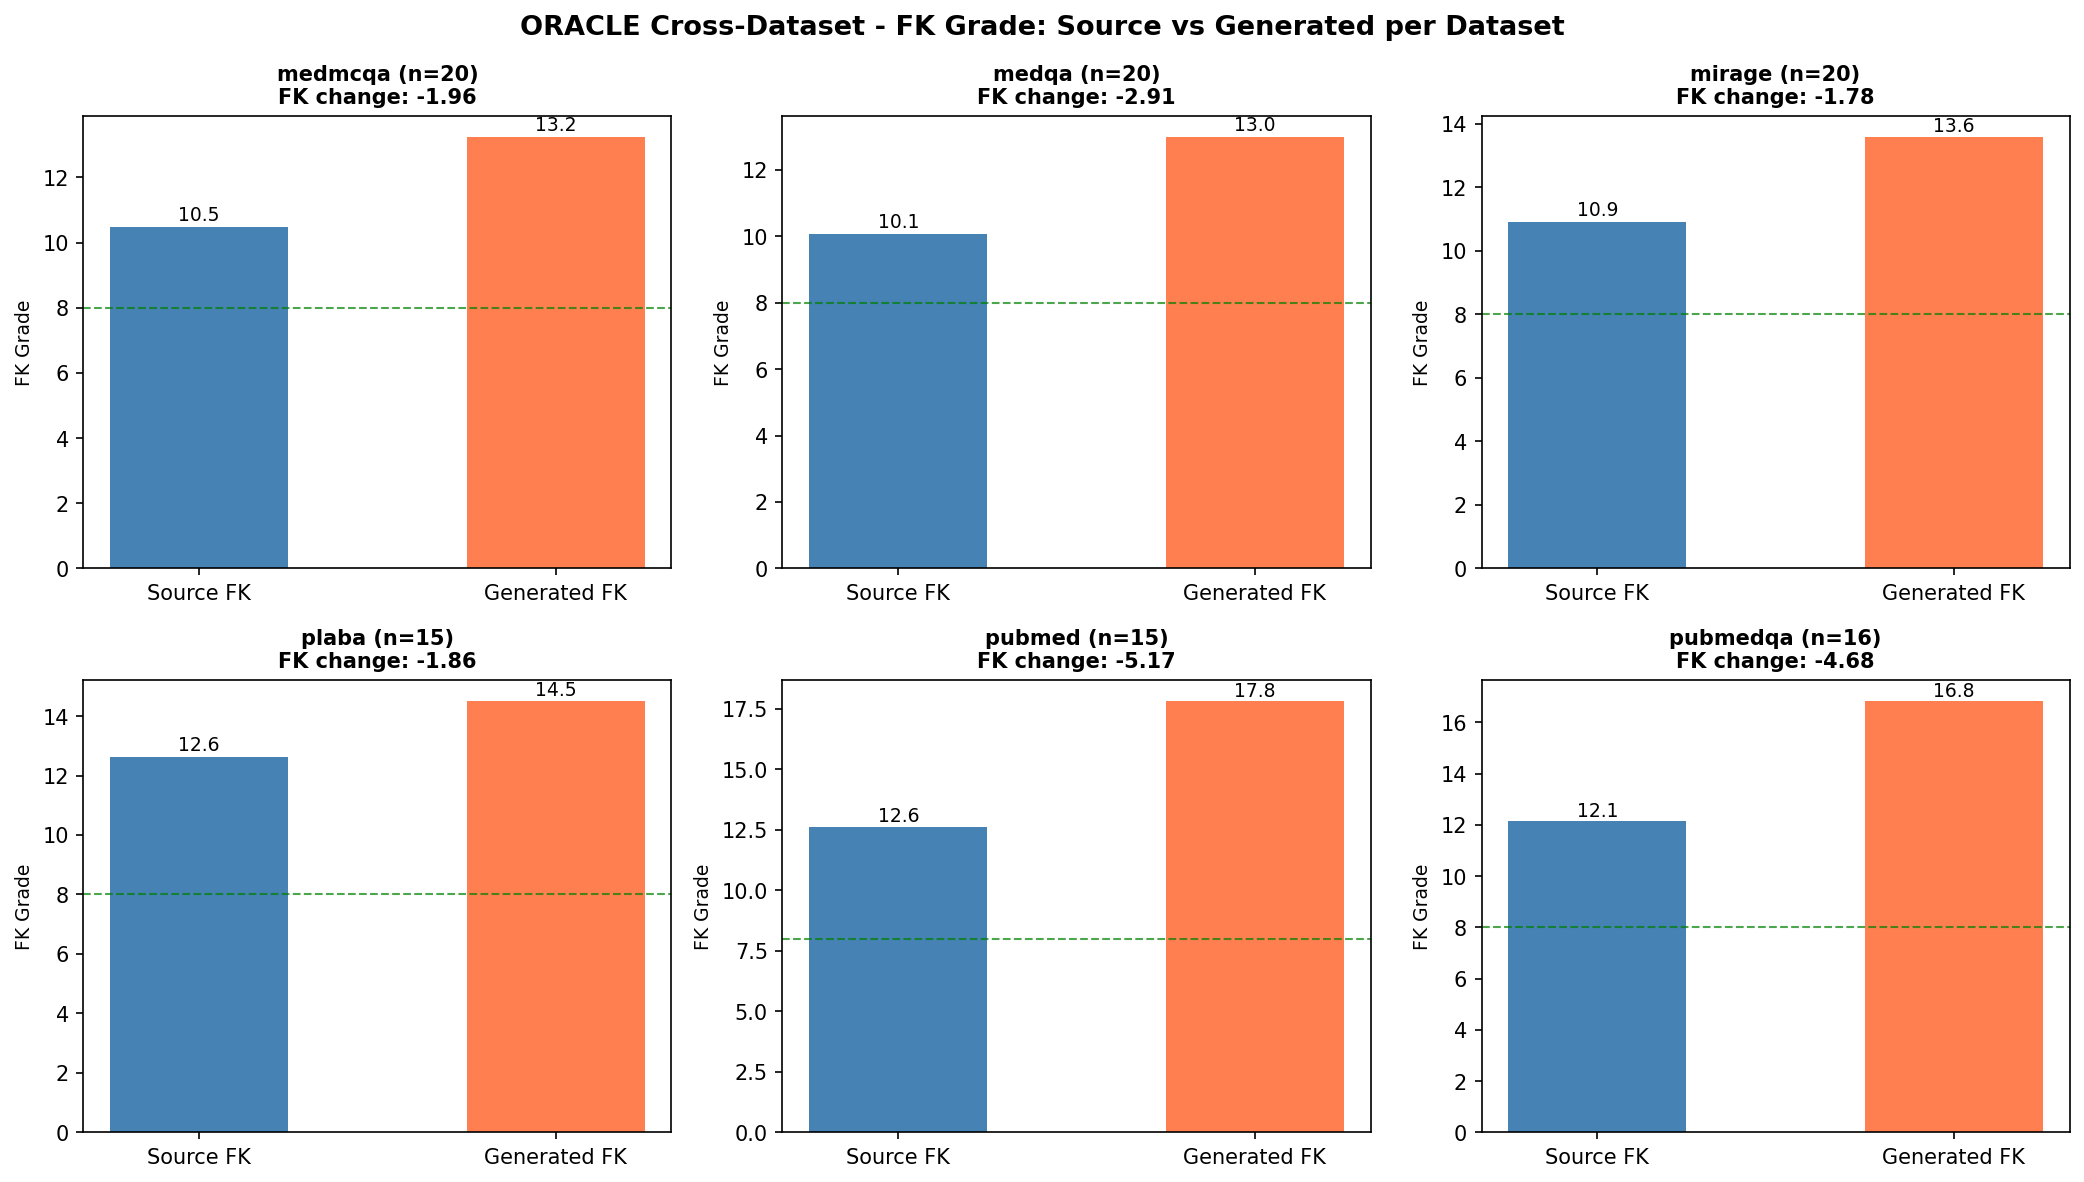

In [6]:
from IPython.display import Image
Image('../figures/stage4/cross_dataset_fk_comparison.png')

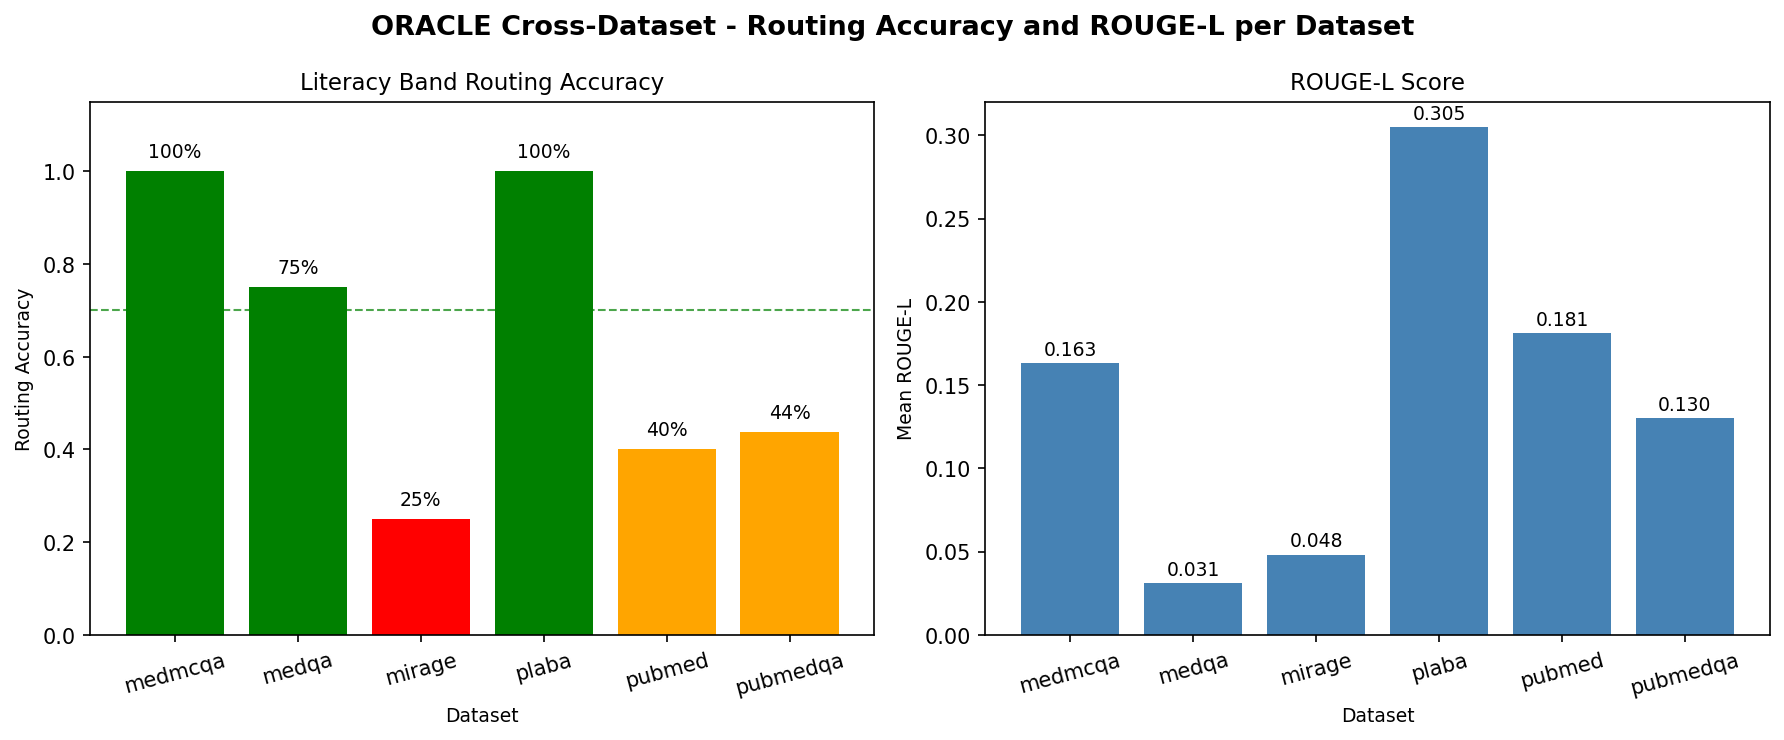

In [7]:
Image('../figures/stage4/cross_dataset_routing_rouge.png')

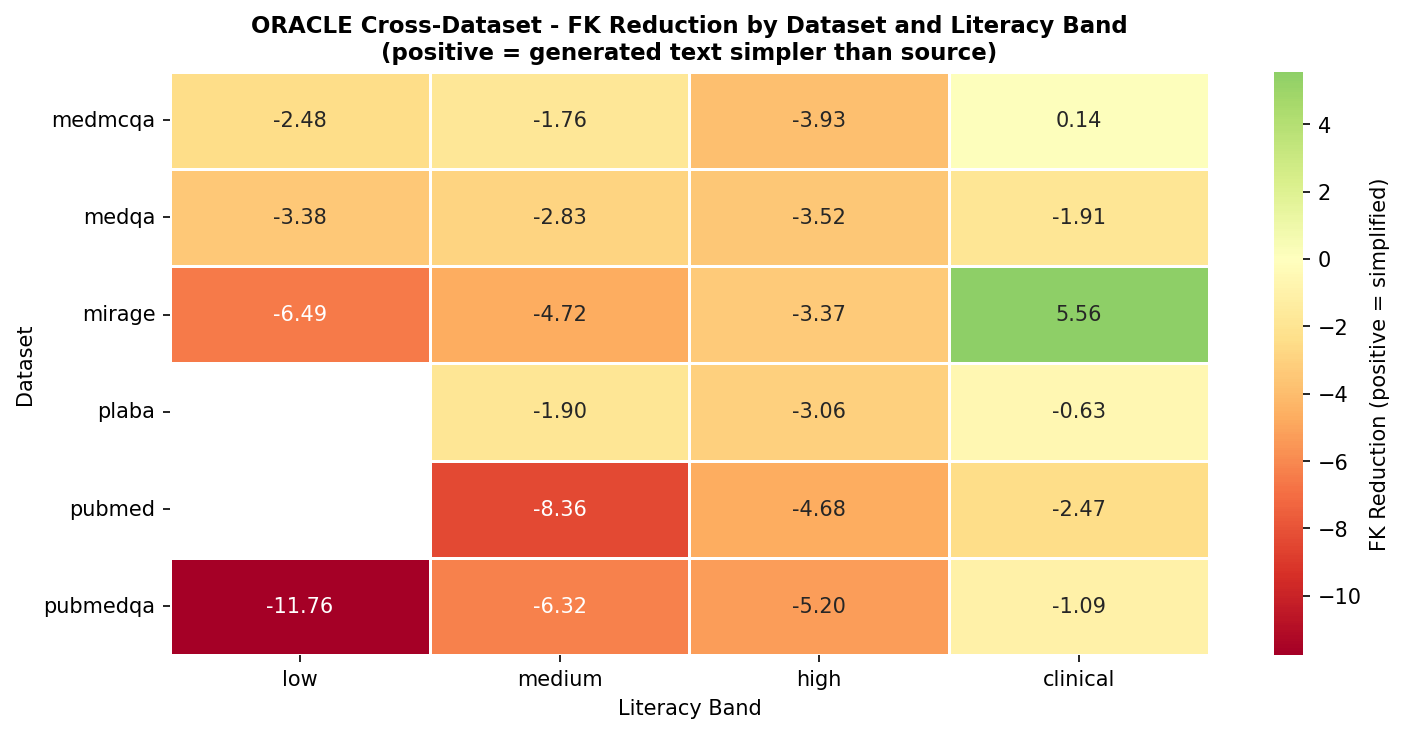

In [8]:
Image('../figures/stage4/cross_dataset_fk_by_band.png')

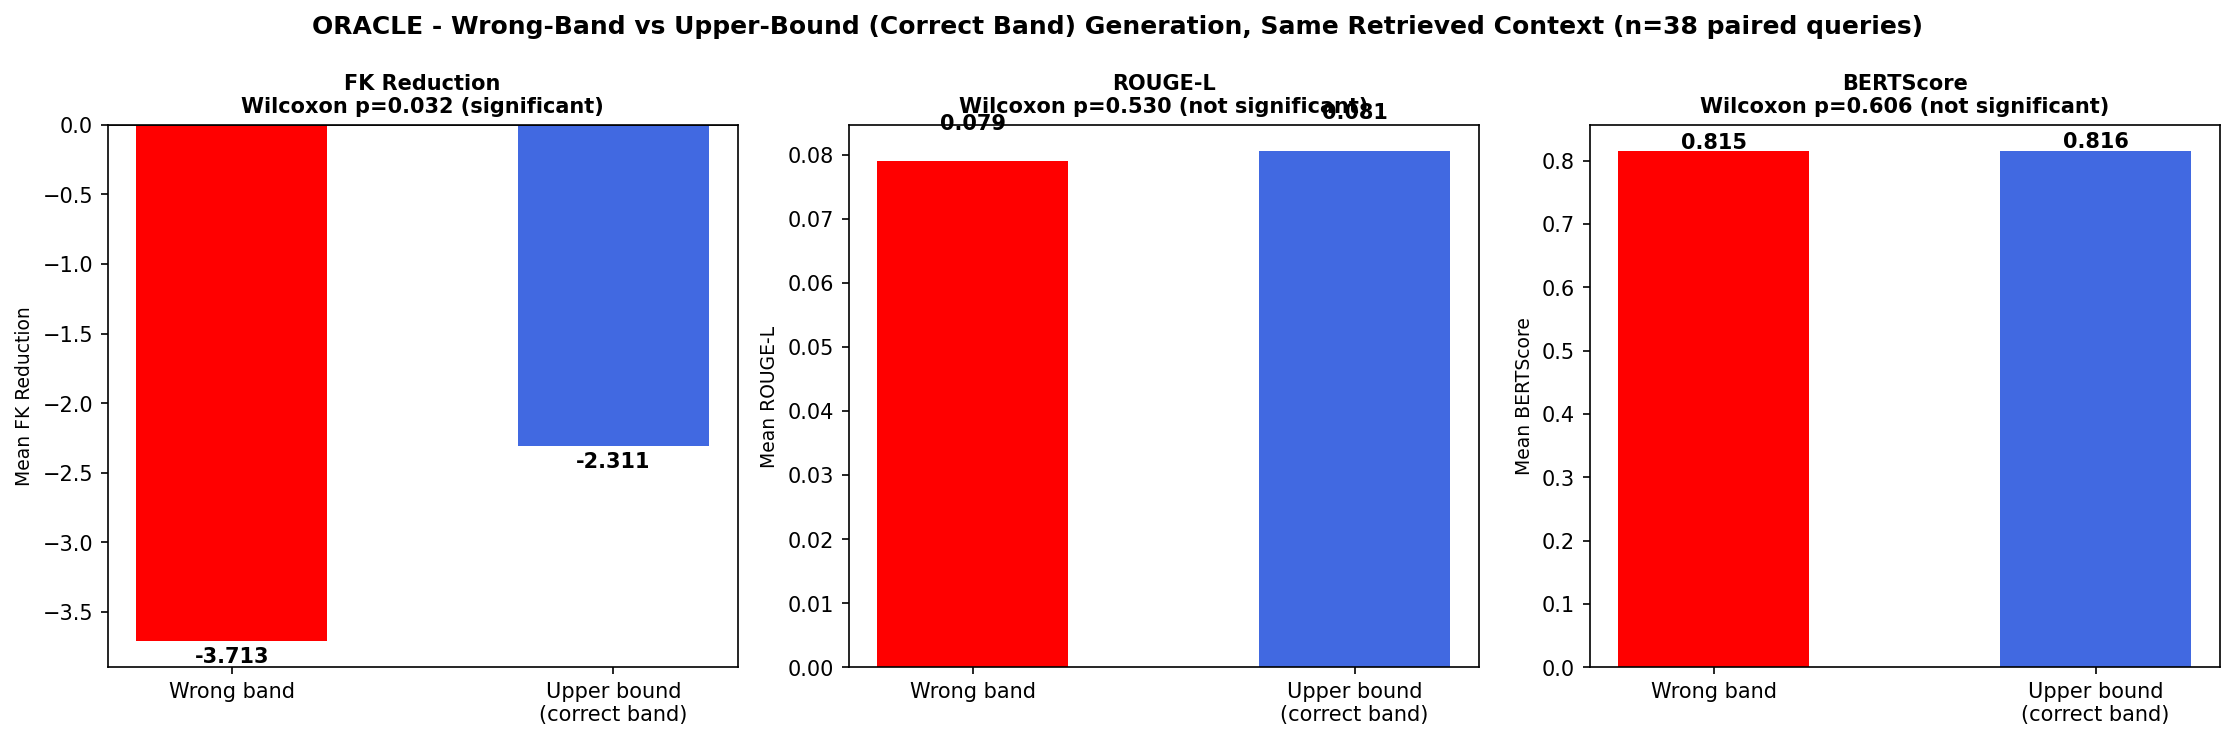

In [9]:
Image('../figures/stage4/cross_dataset_routing_impact.png')